# Week 6 - Function 1 ((15DP, 2D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:
import numpy as np
import torch
import gpytorch

from scipy.stats.qmc import LatinHypercube
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from sklearn.svm import SVC, SVR

from utils.plotting_utils import (
    plot_2D_mean_uncertainty,
    plot_svm_analysis,
    plot_acquisition_comparison,
)

In [2]:
# ── GPyTorch utilities (shared across migrated notebooks) ──────────────────────

class MaternARD_ExactGP(gpytorch.models.ExactGP):
    def __init__(self, X, y, likelihood, n_dims, ls_prior=None):
        super().__init__(X, y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        ls_prior = ls_prior or gpytorch.priors.GammaPrior(3.0, 6.0)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5, ard_num_dims=n_dims,
                lengthscale_prior=ls_prior
            ),
            outputscale_prior=gpytorch.priors.GammaPrior(2.0, 0.15)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def fit_gpytorch_model(X_np, y_np, n_dims, noise=0.01, n_steps=300, lr=0.1, ls_prior=None):
    X_t = torch.tensor(X_np, dtype=torch.float64)
    y_t = torch.tensor(y_np, dtype=torch.float64)
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    likelihood.noise = noise
    model = MaternARD_ExactGP(X_t, y_t, likelihood, n_dims, ls_prior=ls_prior).double()
    likelihood = likelihood.double()
    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    losses = []
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = -mll(model(X_t), y_t)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    model.eval(); likelihood.eval()
    return model, likelihood, losses


def gp_predict(model, likelihood, X_np):
    """Drop-in replacement for sklearn GP.predict(X, return_std=True)."""
    X_t = torch.tensor(X_np, dtype=torch.float64)
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(X_t))
    return pred.mean.numpy(), pred.variance.sqrt().numpy()


def gp_converged_gpytorch(losses, min_loss_drop=0.1, max_final_loss=10.0):
    losses_arr = np.array(losses)
    loss_drop = losses_arr[0] - losses_arr[-1]
    converged = (not np.any(np.isnan(losses_arr))
                 and loss_drop >= min_loss_drop
                 and losses_arr[-1] < max_final_loss)
    return converged, {'loss_drop': loss_drop, 'final_loss': losses_arr[-1]}


# Plan
We now have ((15, 2)) — 15 data points, 2D input — found at `./data/week_6/function_1/`.

1. Load data
2. Preprocessing — **QuantileTransformer only** (log10 removed in week 5: shift constant ~1.004 dwarfs all y values, leaving only 3 distinct log values out of 14, so gp_log learned nothing)
3. Build probabilistic Models — **gp_qt only** with convergence guard (excludes from ensemble if `length_scale` hits bound)
4. SVM Analysis — **two surrogates**: SVM Classifier (C=1, median y_qt threshold → 7/7 split) + SVR(y_qt)
5. Acquisition Function — **2-surrogate ensemble**: GP(y_qt) [if converged] + SVR(y_qt); kappa=8.0 (exploration override)

# 1. Load data

The 13th point (submitted at the end of week 3) landed close to existing points and did not improve the best known output by much. The data distribution is largely unchanged, so this week we focus entirely on fixing modelling issues identified after the week 3 run.

In [3]:
X_train_raw = np.load(r"./data/week_6/function_1/inputs.npy")
y_train_raw = np.load(r"./data/week_6/function_1/outputs.npy")

print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(15, 2), y=(15,)
X range: [0.0787, 0.8839]
y range: [-3.61e-03, 5.62e-06]


# 2. Preprocessing

Outputs span a massive range — most are negative (penalty zone), with the best positive value at ~5.6×10⁻⁶. `StandardScaler` collapses this structure because a single large negative outlier dominates the variance.

**QuantileTransformer** (all 14 points): Rank-based [0, 1] scaling that preserves ordering without being skewed by the outlier. 14 distinct ranks → 14 distinct gradient signals for the GP.

**Why log10 was removed (week 5)**: A log-shift of `abs(y.min()) + 1.0 ≈ 1.004` is ~10¹⁸× larger than 12 of the 14 y values (which span 1e-124 to 1e-15). At float64 precision, `log10(1.004 + 1e-54) == log10(1.004 + 1e-124)` — all 12 near-zero values collapse to the same log value (0.001563), leaving only 3 distinct values. gp_log was learning nothing that gp_qt doesn't already know.

In [4]:
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)

scaler_qt = QuantileTransformer(n_quantiles=len(y_train_raw), output_distribution='uniform')
y_qt = scaler_qt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

print(f"Total points: {len(X_train)}")
print(f"\nQuantileTransformer output range: [{y_qt.min():.4f}, {y_qt.max():.4f}]")
print(f"\nBest point: X={X_train_raw[np.argmax(y_train_raw)]}, y={y_train_raw.max():.2e}, y_qt={y_qt.max():.4f}")

# Show all 14 distinct ranks — confirming QT gives useful gradient (unlike log)
print(f"\nAll 14 y values ranked by QT:")
order = np.argsort(y_train_raw)
for rank, i in enumerate(order):
    print(f"  rank {rank+1:2d}: y={y_train_raw[i]:+.3e}  y_qt={y_qt[i]:.4f}")

Total points: 15

QuantileTransformer output range: [0.0000, 1.0000]

Best point: X=[0.483198 0.47931 ], y=5.62e-06, y_qt=1.0000

All 14 y values ranked by QT:
  rank  1: y=-3.606e-03  y_qt=0.0000
  rank  2: y=-4.513e-15  y_qt=0.0714
  rank  3: y=-2.159e-54  y_qt=0.1429
  rank  4: y=-3.192e-70  y_qt=0.2143
  rank  5: y=-2.089e-91  y_qt=0.2857
  rank  6: y=+3.342e-124  y_qt=0.3571
  rank  7: y=+9.426e-85  y_qt=0.4286
  rank  8: y=+3.607e-81  y_qt=0.5000
  rank  9: y=+4.373e-81  y_qt=0.5714
  rank 10: y=+1.323e-79  y_qt=0.6429
  rank 11: y=+6.230e-48  y_qt=0.7143
  rank 12: y=+1.033e-46  y_qt=0.7857
  rank 13: y=+2.535e-40  y_qt=0.8571
  rank 14: y=+7.711e-16  y_qt=0.9286
  rank 15: y=+5.622e-06  y_qt=1.0000


# 3. Build probabilistic Models

One GP model on QuantileTransformer output (all 14 points):
- **gp_qt**: `length_scale` floored at 0.2 to force smooth interpolation — QT destroys the natural spatial gradient, so without a floor the GP collapses to tiny spikes at each training point.
- `nu=2.5` (smooth Matérn), `alpha=0.01` as observation noise, 30 random restarts.

**Convergence guard**: If gp_qt hits its `length_scale` bound (a `ConvergenceWarning`), `gp_qt_converged = False` and gp_qt is excluded from the acquisition ensemble in section 5. A non-converged GP uses a constrained, non-optimal kernel and can dominate the ensemble with unreliable predictions.

GP(y_qt) training: final_loss=0.6296, loss_drop=1.9873
GP(y_qt) status: INCLUDED
GP(y_qt) ARD length scales: x1=0.3156, x2=0.0738


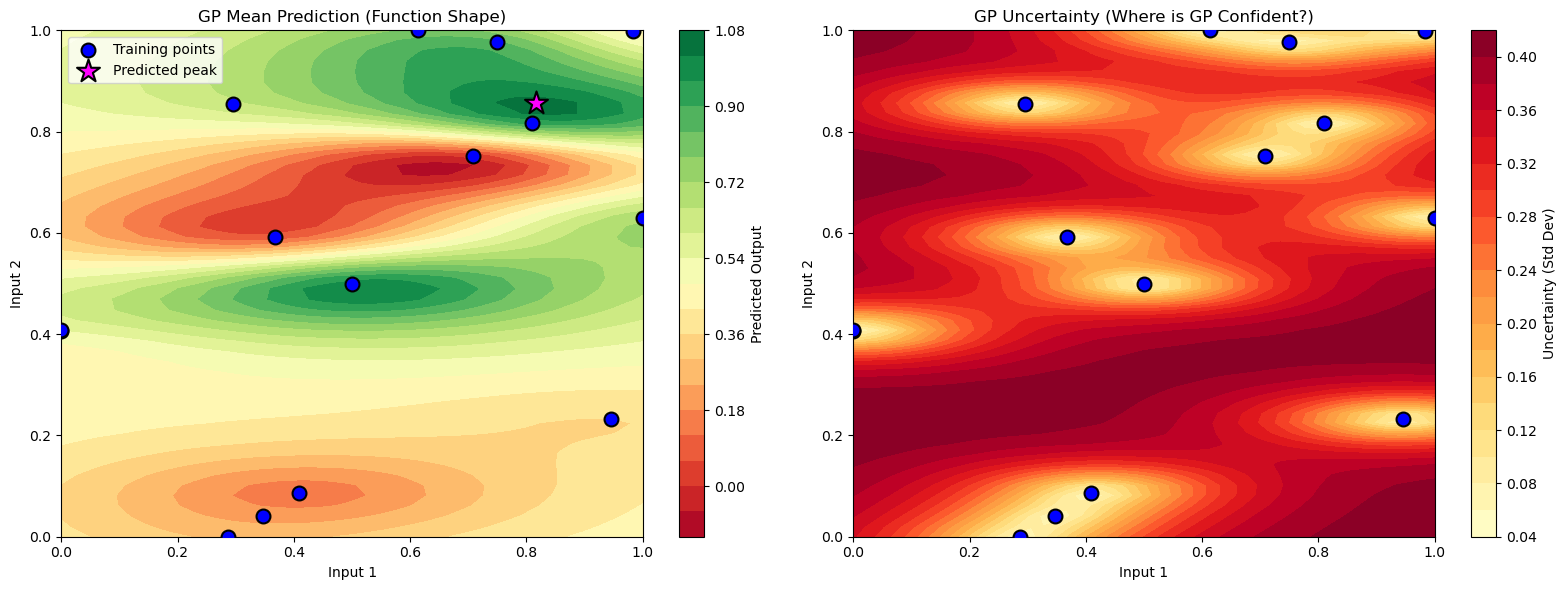

In [5]:
# GP on QuantileTransformer output (all 15 points) — GPyTorch ARD Matern 2.5
# GammaPrior(3, 6) replaces hard length_scale_bounds=(0.2, 5.0).
# The old sklearn GP hit the upper bound (ls→5.0) on every restart → ConvergenceWarning
# → excluded from ensemble. GammaPrior soft prior: mode=0.33, long right tail →
# penalises ls=1000 but never hard-excludes the GP.
n_dims_fn1 = 2
model_qt, likelihood_qt, losses_qt = fit_gpytorch_model(
    X_train, y_qt, n_dims=n_dims_fn1, noise=0.01, n_steps=300, lr=0.1)

gp_qt_converged, conv_info = gp_converged_gpytorch(losses_qt)
print(f"GP(y_qt) training: final_loss={conv_info['final_loss']:.4f}, loss_drop={conv_info['loss_drop']:.4f}")
print(f"GP(y_qt) status: {'INCLUDED' if gp_qt_converged else 'EXCLUDED (did not converge)'}")

ls_qt = model_qt.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
print(f"GP(y_qt) ARD length scales: x1={ls_qt[0]:.4f}, x2={ls_qt[1]:.4f}")

# Create prediction grid
n_grid = 50
x1_range = np.linspace(0, 1, n_grid)
x2_range = np.linspace(0, 1, n_grid)
X1_test, X2_test = np.meshgrid(x1_range, x2_range)
X_grid = np.c_[X1_test.ravel(), X2_test.ravel()]

# Make predictions
mu_gp_qt, sigma_gp_qt = gp_predict(model_qt, likelihood_qt, X_grid)

plot_2D_mean_uncertainty(
   X_train,
   X1_test,
   X2_test,
   mu_gp_qt,
   sigma_gp_qt,
   X_excluded=None,
)

# 4. SVM Analysis

The GP treats every region equally when computing uncertainty. Several points produce strongly negative outputs (a penalty zone), so we use an SVM classifier to learn the boundary between promising and unpromising regions — its P(promising) acts as a soft mask on the acquisition function.

Two models complement gp_qt:
1. **SVM Classifier** — C=1 (soft margin), threshold at `median(y_qt)` → reliable 7/7 split. The QT-based threshold is used because y_qt is uniform in [0, 1] by construction, guaranteeing ~50% positive labels regardless of the raw y distribution.
2. **SVR Surrogate (QuantileTransformer)**: Trained on all 14 points with y_qt — independent surrogate to cross-validate gp_qt.

**Why SVR(log) was removed**: It trained on `y_log_pos` which had only 3 distinct values (machine-precision collapse). It was essentially fitting a constant and then extrapolating to the boundary — no useful signal.

SVM threshold: median(y_qt) = 0.5000 | 7 promising / 8 not promising

=== Support Vectors: 12 / 15 training points (80%) ===
 Idx         Label     x1_orig     x2_orig           y_raw
   3           not      0.8404      0.2647        0.000000
   4           not      0.6501      0.6815       -0.003606
   5           not      0.4104      0.1476       -0.000000
   8           not      0.0825      0.4035        0.000000
  13           not      0.3769      0.5529       -0.000000
  14           not      0.8711      0.8783        0.000000
   0     promising      0.3194      0.7630        0.000000
   2     promising      0.7310      0.7330        0.000000
   7     promising      0.6834      0.8611        0.000000
   9     promising      0.8839      0.5823        0.000000
  10     promising      0.0825      0.4057        0.000000
  12     promising      0.4832      0.4793        0.000006


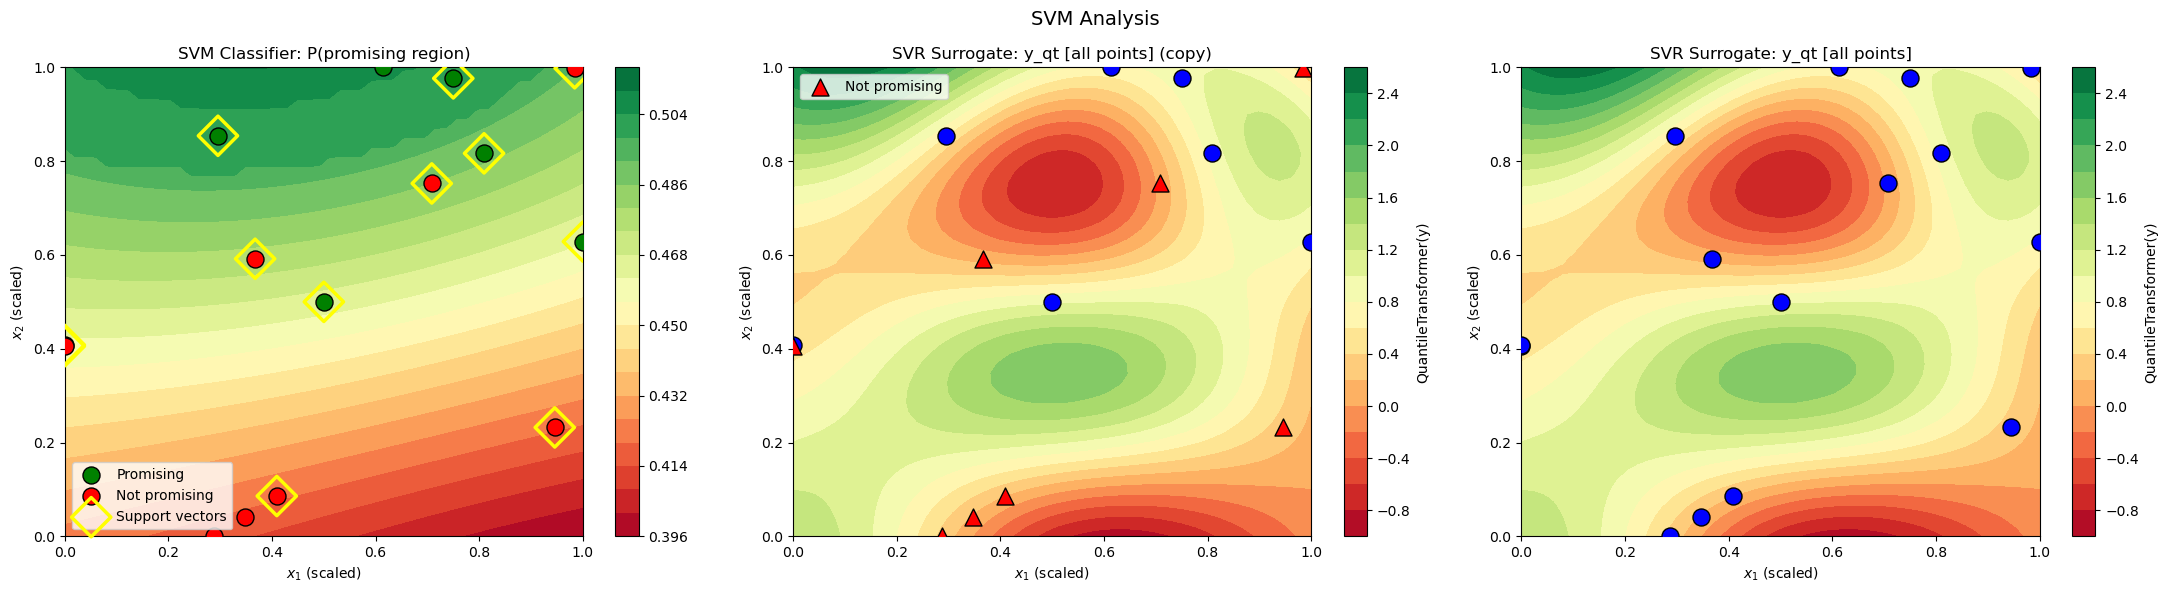


SVR(y_qt) suggests peak near: [0.1643, 0.8799]
  Predicted y_qt: 2.517

SVM Classifier:
  Promising labels: 7 (1=promising), 8 (0=unpromising)
  Grid area classified as promising (P>0.5): 4.7%


In [6]:
# --- SVM Classifier: promising vs not-promising regions ---
# Threshold via median(y_qt): y_qt is uniform in [0,1] by construction, so
# median ≈ 0.49 and gives a reliable 7/7 split regardless of the raw y distribution.
svm_median_threshold_qt = np.median(y_qt)
svm_labels = (y_qt > svm_median_threshold_qt).astype(int)
n_pos_svm = svm_labels.sum()
n_neg_svm = len(svm_labels) - n_pos_svm
print(f"SVM threshold: median(y_qt) = {svm_median_threshold_qt:.4f} | {n_pos_svm} promising / {n_neg_svm} not promising")

# C=10, gamma='auto' (=0.5 for 2D):
# - gamma='auto' (0.5) gives a smooth, broad kernel — unlike 'scale'≈6 which was too local.
# - C=10 enforces a stricter margin so points outside the boundary are not pulled in as SVs.
#   (Previous C=1 was too soft: with 14 balanced points ALL fell inside the wide margin.)
# - This combination avoids both collapse (C=10 + gamma≈6) and all-SVs (C=1 + any gamma).
svm_clf = SVC(kernel='rbf', C=10, gamma='auto', probability=True)
svm_clf.fit(X_train, svm_labels)

# --- Support Vector Analysis ---
sv_indices = svm_clf.support_
support_vec_mask = np.zeros(len(X_train), dtype=bool)
support_vec_mask[sv_indices] = True

X_sv_orig = scaler_X.inverse_transform(X_train[sv_indices])
y_sv_raw  = y_train_raw[sv_indices]
sv_labels_vals = svm_labels[sv_indices]

print(f"\n=== Support Vectors: {len(sv_indices)} / {len(X_train)} training points "
      f"({100*len(sv_indices)/len(X_train):.0f}%) ===")
if len(sv_indices) == len(X_train):
    print("  NOTE: All points are SVs — classes may still be spatially mixed at this C/gamma.")
print(f"{'Idx':>4}  {'Label':>12}  {'x1_orig':>10}  {'x2_orig':>10}  {'y_raw':>14}")
for ti, x_o, y_o, lbl in zip(sv_indices, X_sv_orig, y_sv_raw, sv_labels_vals):
    print(f"{ti:>4}  {'promising' if lbl else 'not':>12}  {x_o[0]:>10.4f}  {x_o[1]:>10.4f}  {y_o:>14.6f}")

# Predict promising probability on the grid
svm_proba = svm_clf.predict_proba(X_grid)[:, 1]

# --- SVR Surrogate on QuantileTransformer output (all 14 points) ---
svr_qt = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.05)
svr_qt.fit(X_train, y_qt)
mu_svr_qt = svr_qt.predict(X_grid)

X_train_promising = X_train[svm_labels == 1]
X_train_unpromising = X_train[svm_labels == 0]
plot_svm_analysis(X1_test, X2_test, svm_proba, mu_svr_qt, mu_svr_qt,
                  X_train, X_train_promising, X_train_unpromising, svm_labels,
                  support_vec_mask=support_vec_mask,
                  panel2_title='SVR Surrogate: y_qt [all points] (copy)',
                  panel2_cbar='QuantileTransformer(y)',
                  panel3_title='SVR Surrogate: y_qt [all points]',
                  panel2_neg_label='Not promising')

# SVR best prediction
best_svr_qt_idx = np.argmax(mu_svr_qt)
best_svr_qt_point = scaler_X.inverse_transform([X_grid[best_svr_qt_idx]])[0]
print(f"\nSVR(y_qt) suggests peak near: [{best_svr_qt_point[0]:.4f}, {best_svr_qt_point[1]:.4f}]")
print(f"  Predicted y_qt: {mu_svr_qt[best_svr_qt_idx]:.3f}")

print(f"\nSVM Classifier:")
print(f"  Promising labels: {svm_labels.sum()} (1=promising), {(svm_labels==0).sum()} (0=unpromising)")
print(f"  Grid area classified as promising (P>0.5): {(svm_proba > 0.5).mean()*100:.1f}%")

# 5. Acquisition Function (SVM-constrained UCB)

**2-surrogate ensemble** (simplified from 4-surrogate in week 4):
- **GP(y_qt)**: UCB = mu + kappa × sigma. Included only if it converged (no `ConvergenceWarning`).
- **SVR(y_qt)**: Point prediction (no sigma). Used as a tie-breaker / sanity check.
- **SVM constraint**: UCB × P(promising) steers evaluations away from the negative-output penalty zone.
- **SVM fail-safe**: If the SVM classifies < 5% of the grid as promising (decision boundary collapse), fall back to uniform weights so the constraint does not silence the entire acquisition surface.

**kappa=8.0** (exploration override): Budget-aware formula gives `5.0 - ((5-1)/13)*3.0 = 4.08`, but we override upward to encourage broader search since the model has had limited spatial coverage after weeks of near-boundary recommendations.

kappa = 8.00 (WEEK 6: exploration override; budget-aware formula gives 3.85)


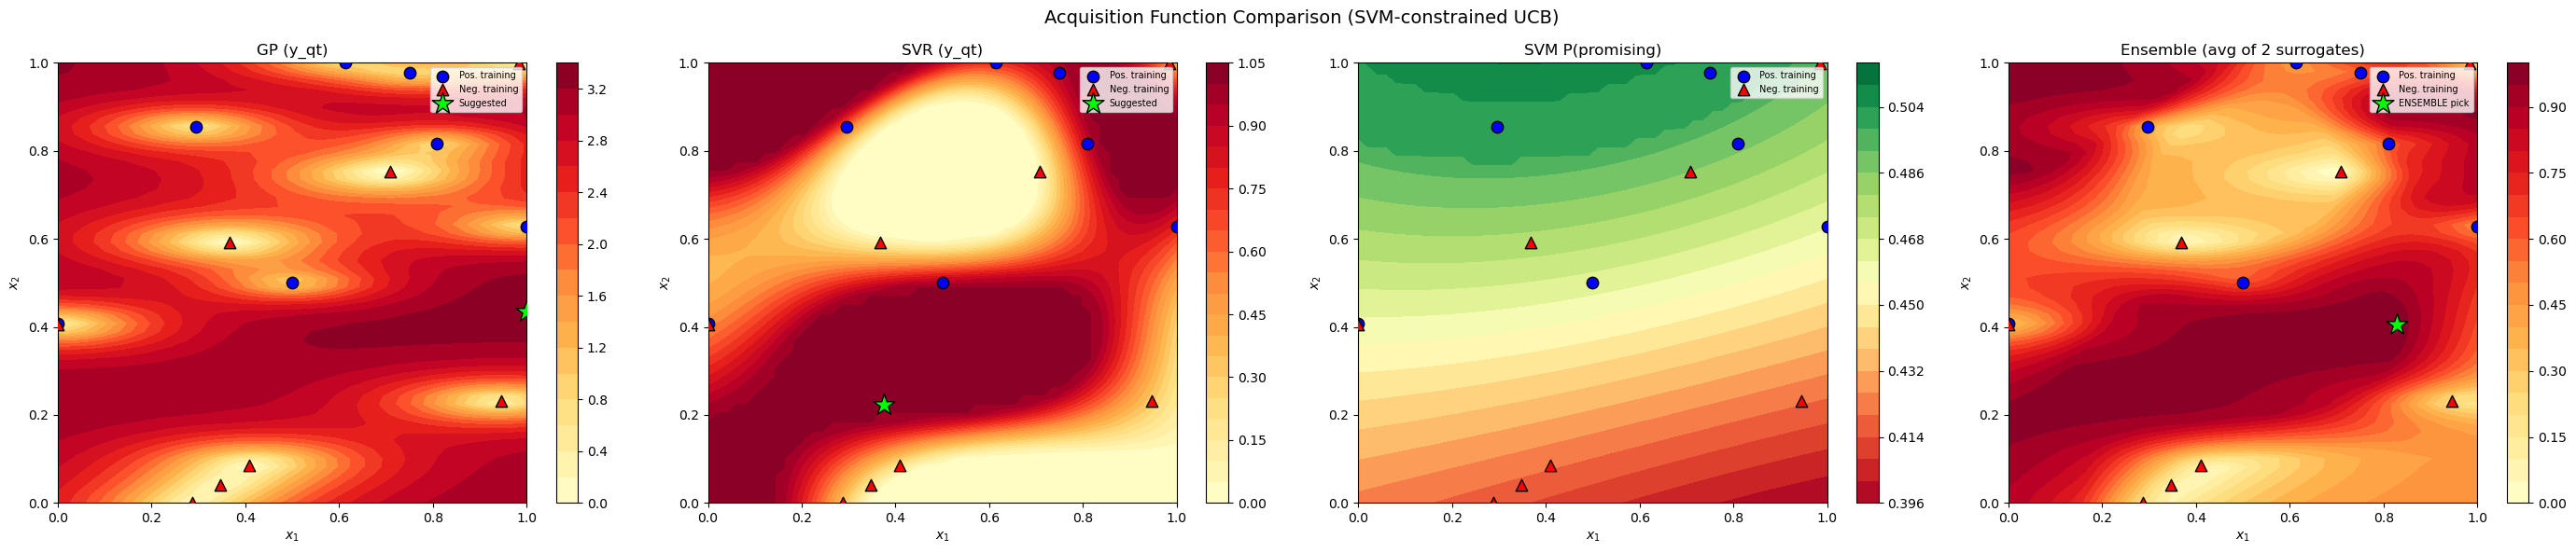


RECOMMENDED NEXT POINT (Ensemble of 2 surrogate(s), 10K LHS candidates)
  Ensemble members: SVR (y_qt), GP (y_qt)
  GP (y_qt) status: INCLUDED

  Input (original space): [0.745334, 0.402867]
  Input (scaled):         [0.827104, 0.404585]
  SVM P(promising):       0.444

  Individual surrogate suggestions (own best point):
    GP (y_qt)           : [0.883365, 0.426983]  SVM P=0.442  ✓
    SVR (y_qt)          : [0.383117, 0.257409]  SVM P=0.436  ✓

  Current best: [0.483198, 0.479310] (y = 5.62e-06)
  SVM grid coverage: 4.7% promising (fail-safe threshold: 5%)

X_next = [0.74533362 0.40286652]

SUBMISSION: 0.745334-0.402867


In [7]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """Upper Confidence Bound: UCB = mean + kappa * std"""
    return mu + kappa * sigma


# --- kappa and WEEK ---
WEEK = 6
kappa = 8.0
print(f"kappa = {kappa:.2f} (WEEK {WEEK}: exploration override; budget-aware formula gives {5.0 - ((WEEK-1)/13)*3.0:.2f})")

# --- Grid-based UCB for visualization (reuses X_grid from section 3) ---
ucb_gp_qt_grid  = upper_confidence_bound(mu_gp_qt,  sigma_gp_qt,  kappa=kappa)
pred_svr_qt_grid = np.clip(mu_svr_qt, 0.0, 1.0)

svm_proba_eff_grid = svm_proba if (svm_proba > 0.5).mean() >= 0.05 else np.ones_like(svm_proba)

def constrained_ucb(ucb_vals, svm_p):
    ucb_shifted = ucb_vals - ucb_vals.min() + 1e-6
    return ucb_shifted * svm_p

surrogates_grid = {
    'GP (y_qt)':  constrained_ucb(ucb_gp_qt_grid,   svm_proba_eff_grid),
    'SVR (y_qt)': constrained_ucb(pred_svr_qt_grid,  svm_proba_eff_grid),
}

def normalize_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

# --- 10K LHS candidates for acquisition argmax (same pattern as all other functions) ---
X_candidates = LatinHypercube(d=2, seed=42).random(n=10_000)

mu_gp_cand, sigma_gp_cand = gp_predict(model_qt, likelihood_qt, X_candidates)
mu_svr_cand = svr_qt.predict(X_candidates)
svm_proba_cand = svm_clf.predict_proba(X_candidates)[:, 1]

if (svm_proba_cand > 0.5).mean() < 0.05:
    print("WARNING: SVM classified <5% of LHS candidates as promising — applying fail-safe (uniform weights).")
    svm_proba_eff_cand = np.ones_like(svm_proba_cand)
else:
    svm_proba_eff_cand = svm_proba_cand

ucb_gp_cand  = upper_confidence_bound(mu_gp_cand, sigma_gp_cand, kappa=kappa)
pred_svr_cand = np.clip(mu_svr_cand, 0.0, 1.0)

ucb_c_gp_cand  = constrained_ucb(ucb_gp_cand,  svm_proba_eff_cand)
ucb_c_svr_cand = constrained_ucb(pred_svr_cand, svm_proba_eff_cand)

surrogates_cand = {
    'GP (y_qt)':  ucb_c_gp_cand,
    'SVR (y_qt)': ucb_c_svr_cand,
}

# --- Ensemble on LHS candidates ---
ensemble_members = ['SVR (y_qt)']
if gp_qt_converged:
    ensemble_members.append('GP (y_qt)')

norm_ucb_cand = {name: normalize_01(surrogates_cand[name]) for name in ensemble_members}
ensemble_ucb_cand = sum(norm_ucb_cand[m] for m in ensemble_members) / len(ensemble_members)

best_ensemble_idx = np.argmax(ensemble_ucb_cand)
x_next_norm = X_candidates[best_ensemble_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

# Best point per surrogate (from LHS candidates)
best_points = {}
for name, ucb_vals in surrogates_cand.items():
    idx = np.argmax(ucb_vals)
    best_points[name] = {
        'idx': idx,
        'norm': X_candidates[idx],
        'orig': scaler_X.inverse_transform([X_candidates[idx]])[0],
        'svm_p': svm_proba_cand[idx],
    }

# --- Plot using grid-based values for contour structure ---
norm_ucb_grid = {name: normalize_01(surrogates_grid[name]) for name in ensemble_members}
ensemble_ucb_grid = sum(norm_ucb_grid[m] for m in ensemble_members) / len(ensemble_members)

plot_acquisition_comparison(X1_test, X2_test, surrogates_grid, svm_proba,
                            ensemble_ucb_grid, X_train_promising, X_train_unpromising,
                            best_points, x_next_norm)

# --- Summary ---
gp_qt_status = "INCLUDED" if gp_qt_converged else "EXCLUDED (did not converge)"

print(f"\n{'='*80}")
print(f"RECOMMENDED NEXT POINT (Ensemble of {len(ensemble_members)} surrogate(s), 10K LHS candidates)")
print(f"{'='*80}")
print(f"  Ensemble members: {', '.join(ensemble_members)}")
print(f"  GP (y_qt) status: {gp_qt_status}")
print(f"\n  Input (original space): [{x_next_orig[0]:.6f}, {x_next_orig[1]:.6f}]")
print(f"  Input (scaled):         [{x_next_norm[0]:.6f}, {x_next_norm[1]:.6f}]")
print(f"  SVM P(promising):       {svm_proba_cand[best_ensemble_idx]:.3f}")

print(f"\n  Individual surrogate suggestions (own best point):")
for name, bp in best_points.items():
    in_ens = "✓" if name in ensemble_members else "✗ excluded"
    print(f"    {name:20s}: [{bp['orig'][0]:.6f}, {bp['orig'][1]:.6f}]  SVM P={bp['svm_p']:.3f}  {in_ens}")

print(f"\n  Current best: [{X_train_raw[np.argmax(y_train_raw)][0]:.6f}, {X_train_raw[np.argmax(y_train_raw)][1]:.6f}] (y = {y_train_raw.max():.2e})")
print(f"  SVM grid coverage: {(svm_proba > 0.5).mean()*100:.1f}% promising (fail-safe threshold: 5%)")

X_next = x_next_orig
print(f"\nX_next = {X_next}")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {'-'.join(f'{x:.6f}' for x in x_next_orig)}")
